# Last 10 Bitcoin Price Predictions Comparison
This notebook compares the last 10 price predictions (separated by commas) from both the enhanced and base models.

## Install Required Libraries

In [1]:
!pip install transformers datasets torch peft accelerate matplotlib seaborn pandas numpy

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import json
import re



/tmp/xx/grpo_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!CUDA_VISIBLE_DEVICES=3

## Load Required Libraries and Models

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# Define paths
base_model_id = './Qwen3-4B-Instruct-2507'
adapter_path = './qwen_bitcoin_chat_fast_more_longer_explanation_v2/checkpoint-200'
output_merged_model_path = './Qwen3-4B-merged-bitcoin-chat' # Path to save the new model

base_qwen_tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    trust_remote_code=True
)
if base_qwen_tokenizer.pad_token is None:
    base_qwen_tokenizer.pad_token = base_qwen_tokenizer.eos_token
# base_qwen_tokenizer = base_qwen_tokenizer
# 2. Load the base model
base_qwen_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    trust_remote_code=True
)

# 3. Resize token embeddings
base_qwen_model.resize_token_embeddings(len(tokenizer))

# 4. Load the LoRA adapter
print("Loading LoRA adapter from:", adapter_path)
enhanced_model = base_qwen_model
# enhanced_model.eval()
print("\n✅ Adapter loaded successfully!")


# # --- 5. MERGE THE ADAPTER INTO THE BASE MODEL ---
# print("\nMerging adapter...")
# merged_model = enhanced_model.merge_and_unload()
# print("✅ Model merged successfully!")
# enhanced_model = merged_model
# `merged_model` is now a standard AutoModelForCausalLM, not a PeftModel.


# # --- 6. (Optional but Recommended) SAVE THE MERGED MODEL ---
# print(f"Saving merged model to {output_merged_model_path}...")
# merged_model.save_pretrained(output_merged_model_path)
# tokenizer.save_pretrained(output_merged_model_path)
# print("✅ Merged model and tokenizer saved.")

# You can now load and use this new model directly without PEFT
# from transformers import AutoModelForCausalLM
# enhanced_model = AutoModelForCausalLM.from_pretrained("./Qwen3-4B-merged-bitcoin-chat")

`torch_dtype` is deprecated! Use `dtype` instead!



Loading checkpoint shards:   0%|                                          | 0/3 [00:00<?, ?it/s]


Loading checkpoint shards:  33%|███████████▎                      | 1/3 [00:03<00:06,  3.20s/it]


Loading checkpoint shards:  67%|██████████████████████▋           | 2/3 [00:07<00:03,  3.79s/it]


Loading checkpoint shards: 100%|██████████████████████████████████| 3/3 [00:07<00:00,  2.48s/it]

Loading LoRA adapter from: ./qwen_bitcoin_chat_fast_more_longer_explanation_v2/checkpoint-200

✅ Adapter loaded successfully!


## Load Test Dataset

In [5]:
# Load the enhanced dataset
test_dataset = load_dataset('tahamajs/bitcoin-enhanced-prediction-dataset-with-local-comprehensive-news', split='train')
print(f"Loaded {len(test_dataset)} test samples")
shuffled_dataset = test_dataset.shuffle(seed=42)


Loaded 2303 test samples


## Utility Functions for Price Extraction

In [6]:
from typing import Dict, Any, Union


def extract_trading_recommendation_from_text(text):
    """Extract structured trading recommendation with 10-day forecast from model output"""
    import json
    
    # Clean the text first
    text = text.strip()
    
    # Method 1: Try to find complete JSON structure
    json_patterns = [
        r'\{[^{}]*"forecast_10d"[^{}]*\}',  # Simple JSON
        r'\{(?:[^{}]|{[^{}]*})*"forecast_10d"(?:[^{}]|{[^{}]*})*\}',  # Nested JSON
    ]
    
    for pattern in json_patterns:
        matches = re.findall(pattern, text, re.DOTALL)
        for match in matches:
            try:
                cleaned_json = match.strip()
                # Fix common JSON issues
                cleaned_json = re.sub(r',\s*}', '}', cleaned_json)  # Remove trailing commas
                cleaned_json = re.sub(r',\s*]', ']', cleaned_json)   # Remove trailing commas in arrays
                
                parsed = json.loads(cleaned_json)
                
                # Validate required fields
                if all(key in parsed for key in ['action', 'confidence', 'forecast_10d']):
                    # Ensure forecast_10d is a list of numbers
                    if isinstance(parsed['forecast_10d'], list) and len(parsed['forecast_10d']) > 0:
                        try:
                            parsed['forecast_10d'] = [float(x) for x in parsed['forecast_10d']]
                            return parsed
                        except (ValueError, TypeError):
                            continue
            except json.JSONDecodeError:
                continue
    
    # Method 2: Try to extract JSON from code blocks
    code_block_pattern = r'```(?:json)?\s*(\{.*?\})\s*```'
    code_matches = re.findall(code_block_pattern, text, re.DOTALL)
    for match in code_matches:
        try:
            parsed = json.loads(match.strip())
            if 'forecast_10d' in parsed:
                return parsed
        except json.JSONDecodeError:
            continue
    
    # Method 3: Try to find any JSON-like structure
    bracket_pattern = r'\{[^{}]*\}'
    bracket_matches = re.findall(bracket_pattern, text, re.DOTALL)
    for match in bracket_matches:
        try:
            parsed = json.loads(match.strip())
            if isinstance(parsed, dict) and 'forecast_10d' in parsed:
                return parsed
        except json.JSONDecodeError:
            continue
    
    # Method 4: Extract forecast_10d array separately
    forecast_patterns = [
        r'"forecast_10d"\s*:\s*\[([^\]]+)\]',
        r'forecast_10d["\']?\s*:\s*\[([^\]]+)\]',
        r'\[(\d+(?:\.\d+)?(?:\s*,\s*\d+(?:\.\d+)?){9,})\]'  # Array of 10+ numbers
    ]
    
    for pattern in forecast_patterns:
        forecast_match = re.search(pattern, text, re.IGNORECASE)
        if forecast_match:
            try:
                price_str = forecast_match.group(1)
                # Handle different separators
                price_str = re.sub(r'\s+', ' ', price_str)  # Normalize whitespace
                prices = []
                
                # Try comma separation first
                if ',' in price_str:
                    prices = [float(p.strip()) for p in price_str.split(',') if p.strip()]
                # Try space separation
                elif ' ' in price_str:
                    prices = [float(p.strip()) for p in price_str.split(' ') if p.strip()]
                else:
                    prices = [float(price_str.strip())]
                
                if len(prices) >= 5:  # At least 5 prices found
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': prices[:10],  # Take first 10
                        'stop_loss': None,
                        'take_profit': None
                    }
            except (ValueError, TypeError):
                continue
    
    # Method 5: Extract any comma-separated numbers (fallback)
    number_patterns = [
        r'(\d+(?:\.\d+)?(?:\s*,\s*\d+(?:\.\d+)?)+)',  # Comma-separated numbers
        r'(\d+(?:\.\d+)?(?:\s+\d+(?:\.\d+)?)+)',      # Space-separated numbers
    ]
    
    for pattern in number_patterns:
        matches = re.findall(pattern, text)
        if matches:
            try:
                # Take the longest sequence
                longest_match = max(matches, key=len)
                if ',' in longest_match:
                    prices = [float(p.strip()) for p in longest_match.split(',') if p.strip()]
                else:
                    prices = [float(p.strip()) for p in longest_match.split() if p.strip()]
                
                if len(prices) >= 3:  # At least 3 prices
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': prices[:10],
                        'stop_loss': None,
                        'take_profit': None
                    }
            except (ValueError, TypeError):
                continue
    
    # Method 6: Single number fallback
    single_number_pattern = r'(\d+(?:\.\d+)?)'
    single_matches = re.findall(single_number_pattern, text)
    if single_matches:
        try:
            # Take the first reasonable price (between 1000 and 200000)
            for match in single_matches:
                price = float(match)
                if 1000 <= price <= 200000:  # Reasonable Bitcoin price range
                    return {
                        'action': 'UNKNOWN',
                        'confidence': 0,
                        'forecast_10d': [price],
                        'stop_loss': None,
                        'take_profit': None
                    }
        except ValueError:
            pass
    
    return None

def extract_last_10_prices_from_text(text):
    """Extract the last 10 price predictions from model output (backward compatibility)"""
    recommendation = extract_trading_recommendation_from_text(text)
    if recommendation and 'forecast_10d' in recommendation:
        return recommendation['forecast_10d']
    return []

def extract_all_prices_from_text(text):
    """Extract all price predictions from model output (backward compatibility)"""
    return extract_last_10_prices_from_text(text)

def format_input_enhanced(example):
    """Format input for the enhanced model"""
    instruction = example.get('instruction', '')
    user_input = example.get('input', '')
    
    # More explicit prompt for JSON output
    enhanced_instruction = """You are a Bitcoin investment advisor. Based on the provided market data and news, provide a trading recommendation in JSON format.

IMPORTANT: Your response must be a valid JSON object with exactly this structure:
{
  "action": "BUY" or "SELL" or "HOLD",
  "confidence": number between 0-100,
  "stop_loss": number (price),
  "take_profit": number (price),
  "forecast_10d": [price1, price2, price3, price4, price5, price6, price7, price8, price9, price10]
}

Example:
{"action":"SELL","confidence":68,"stop_loss":9593.73,"take_profit":8370.01,"forecast_10d":[9174.91, 8277.01, 6955.27, 7754.00, 7621.30, 8265.59, 8736.98, 8621.90, 8129.97, 8926.57]}

Return ONLY the JSON object, no other text."""
    
    messages = [
        {'role': 'system', 'content': enhanced_instruction},
        {'role': 'user', 'content': f"{instruction}\n\n{user_input}\n\nProvide your trading recommendation as a JSON object only:"}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_input_base(example):
    """Format input for base Qwen model"""
    instruction = example.get('instruction', '')
    user_input = example.get('input', '')
    
    bitcoin_instruction = """You are a Bitcoin investment advisor. Based on the provided market data and news, provide a trading recommendation in JSON format.

IMPORTANT: Your response must be a valid JSON object with exactly this structure:
{
  "action": "BUY" or "SELL" or "HOLD",
  "confidence": number between 0-100,
  "stop_loss": number (price),
  "take_profit": number (price),
  "forecast_10d": [price1, price2, price3, price4, price5, price6, price7, price8, price9, price10]
}

Example:
{"action":"SELL","confidence":68,"stop_loss":9593.73,"take_profit":8370.01,"forecast_10d":[9174.91, 8277.01, 6955.27, 7754.00, 7621.30, 8265.59, 8736.98, 8621.90, 8129.97, 8926.57]}

Return ONLY the JSON object, no other text."""
    
    messages = [
        {'role': 'system', 'content': bitcoin_instruction},
        {'role': 'user', 'content': f"{instruction}\n\n{user_input}\n\nProvide your trading recommendation as a JSON object only:"}
    ]
    return base_qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("Utility functions loaded!")

def post_process_recommendation(recommendation, current_price=None):
    """Post-process and validate trading recommendation"""
    if not recommendation:
        return None
    
    # Ensure all required fields exist
    processed = {
        'action': recommendation.get('action', 'UNKNOWN').upper(),
        'confidence': max(0, min(100, int(recommendation.get('confidence', 0)))),
        'forecast_10d': recommendation.get('forecast_10d', []),
        'stop_loss': recommendation.get('stop_loss'),
        'take_profit': recommendation.get('take_profit')
    }
    
    # Validate and clean forecast_10d
    if processed['forecast_10d']:
        # Filter out unreasonable prices
        valid_prices = []
        for price in processed['forecast_10d']:
            try:
                price_float = float(price)
                # Bitcoin price range validation (conservative range)
                if 100 <= price_float <= 1000000:
                    valid_prices.append(price_float)
            except (ValueError, TypeError):
                continue
        
        processed['forecast_10d'] = valid_prices[:10]  # Keep max 10 prices
    
    # Validate action
    valid_actions = ['BUY', 'SELL', 'HOLD', 'UNKNOWN']
    if processed['action'] not in valid_actions:
        processed['action'] = 'UNKNOWN'
    
    # Add validation flags
    processed['is_valid'] = len(processed['forecast_10d']) > 0
    processed['forecast_length'] = len(processed['forecast_10d'])
    
    return processed

def format_input(example: Union[Dict[str, str], str], tokenizer: Any) -> str:
    """
    Generic function to format input for a chat model.
    Handles both dictionary and plain string inputs for the 'example'.
    """
    messages = []
    
    # Check if the example is a dictionary (the expected format)
    if isinstance(example, dict):
        messages = [
            {'role': 'system', 'content': example.get('instruction', 'You are a helpful assistant.')},
            {'role': 'user', 'content': example.get('input', '')}
        ]
    # NEW: Handle the case where the example is just a string
    elif isinstance(example, str):
        messages = [
            {'role': 'system', 'content': 'You are a helpful assistant.'},
            {'role': 'user', 'content': example} # Use the whole string as user input
        ]
    else:
        # Handle unexpected types if necessary
        raise TypeError(f"Unsupported type for 'example': {type(example)}")

    return tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True,
        enable_thinking=False
    )


Utility functions loaded!


## Generate Last 10 Price Predictions

Generating price predictions for 200 samples...




Processing Samples:   0%|                                               | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Processing Samples:   0%|▏                                    | 1/200 [00:22<1:13:23, 22.13s/it]


Processing Samples:   1%|▍                                      | 2/200 [00:35<55:42, 16.88s/it]

...


Processing Samples:  99%|████████████████████████████████████▋| 198/200 [56:00<00:31, 15.56s/it]


Processing Samples: 100%|████████████████████████████████████▊| 199/200 [56:14<00:14, 14.94s/it]


Processing Samples: 100%|█████████████████████████████████████| 200/200 [56:28<00:00, 14.81s/it]


Processing Samples: 100%|█████████████████████████████████████| 200/200 [56:28<00:00, 16.94s/it]


✅ Generated predictions for 200 samples!

Preparing data for metric calculation...

📊 Calculating metrics based on 200 valid forecast samples and 200 valid action samples.

========================= REGRESSION METRICS =========================
Lower is better for MSE, RMSE, and MAE. Higher is better for R-Squared.

                Enhanced Model
MSE               963,270.0087
RMSE                  981.4632
MAE                   732.1549
R-Squared (R²)          0.4843

======================== CLASSIFICATION METRICS ========================
Accuracy, Precision, Recall, and F1-Score are reported. Higher is better (range 0-1).

--- Enhanced Model ---
Overall Accuracy: 0.3800

              precision    recall  f1-score   support

         BUY       0.51      0.36      0.42        83
        HOLD       0.09      0.38      0.14        16
        SELL       0.56      0.40      0.47       101

    accuracy                           0.38       200
   macro avg       0.39      0.38      0.34  

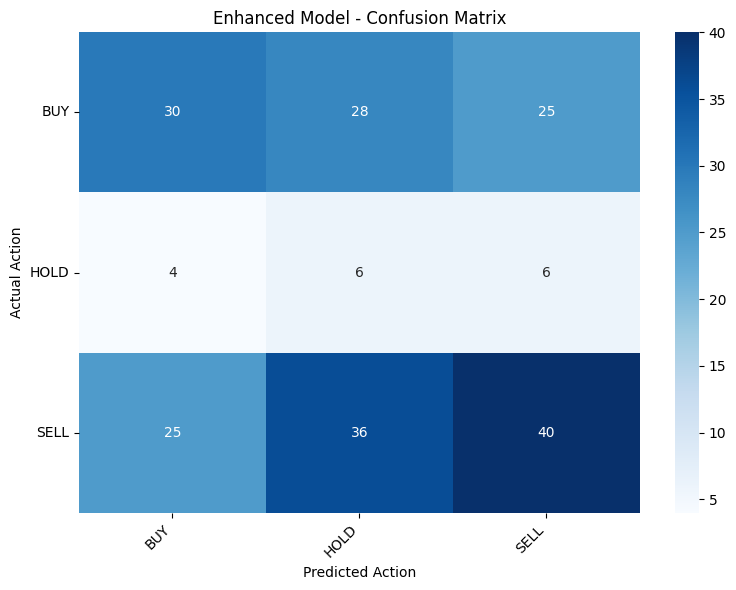


✅ Metric calculation and visualization complete.


In [7]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Assume the following are already loaded and defined:
# enhanced_model, tokenizer, test_dataset, format_input, 
# extract_trading_recommendation_from_text

# --- Helper Functions ---

def generate_prediction(model, tokenizer, text_input):
    """
    Encapsulates the model generation logic to avoid code duplication.
    """
    inputs = tokenizer(
        text_input,
        return_tensors='pt',
        truncation=True,
        max_length=10000
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2048,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated_text

def _get_forecast_prices(recommendation: dict) -> list:
    """
    Safely extracts the 'forecast_10d' list from a recommendation dictionary.
    """
    if not recommendation or 'forecast_10d' not in recommendation:
        return []
    prices = recommendation['forecast_10d']
    return prices if isinstance(prices, list) else []

def plot_confusion_matrix(cm, class_names, title):
    """
    Renders a confusion matrix using Seaborn's heatmap.
    """
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    plt.figure(figsize=(8, 6))
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
    except ValueError:
        print(f"Error creating heatmap for {title}. Skipping.")
        return
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    plt.ylabel('Actual Action')
    plt.xlabel('Predicted Action')
    plt.title(title)
    plt.tight_layout()
    plt.show()


# --- Main Prediction Loop ---
num_samples = 200
results = []
print(f"Generating price predictions for {num_samples} samples...\n")

for i in tqdm(range(min(num_samples, len(test_dataset))), desc="Processing Samples"):
    test_example = test_dataset[i]

    # Step 1: Generate Predictions for the Enhanced Model
    enhanced_prompt = format_input(test_example, tokenizer)
    enhanced_generated = generate_prediction(enhanced_model, tokenizer, enhanced_prompt)

    # Step 2: Extract and Process Data
    enhanced_recommendation = extract_trading_recommendation_from_text(enhanced_generated)
    actual_recommendation = extract_trading_recommendation_from_text(test_example.get('output', ''))

    enhanced_prices_full = _get_forecast_prices(enhanced_recommendation)
    actual_prices_full = _get_forecast_prices(actual_recommendation)

    # Step 3: Store Results
    sample_result = {
        'sample_id': i,
        'enhanced_recommendation': enhanced_recommendation,
        'actual_recommendation': actual_recommendation,
        'enhanced_last_10': enhanced_prices_full[-10:],
        'actual_last_10': actual_prices_full[-10:],
    }
    results.append(sample_result)

print(f"\n✅ Generated predictions for {len(results)} samples!")

# ------------------------------------------------------------------------------------
# --- COMPREHENSIVE METRICS CALCULATION (ENHANCED MODEL) ---
# ------------------------------------------------------------------------------------

# --- 1. Data Preparation ---
all_actual_prices, all_enhanced_prices = [], []
all_actual_actions, all_enhanced_actions = [], []

print("\nPreparing data for metric calculation...")
for res in results:
    actual_prices = res['actual_last_10']
    enhanced_prices = res['enhanced_last_10']

    # A. Process valid regression samples (where forecast lengths match)
    if len(actual_prices) == 10 and len(enhanced_prices) == 10:
        all_actual_prices.extend(actual_prices)
        all_enhanced_prices.extend(enhanced_prices)

        # B. Process valid classification samples (where an action exists)
        actual_action = res.get('actual_recommendation', {}).get('action')
        enhanced_action = res.get('enhanced_recommendation', {}).get('action')

        if actual_action and enhanced_action:
            all_actual_actions.append(actual_action)
            all_enhanced_actions.append(enhanced_action)
        else:
             print(f"  - WARNING: Skipping action for Sample {res['sample_id']} due to missing action value.")
    else:
        print(f"  - WARNING: Skipping forecast for Sample {res['sample_id']} due to mismatched forecast lengths.")

# Check if we have enough data to proceed
if not all_actual_prices or not all_actual_actions:
    print("\n❌ Not enough valid data to calculate comprehensive metrics. Exiting.")
else:
    print(f"\n📊 Calculating metrics based on {len(all_actual_prices) // 10} valid forecast samples and {len(all_actual_actions)} valid action samples.")

    # Convert lists to NumPy arrays for efficient calculations
    actual_np = np.array(all_actual_prices)
    enhanced_np = np.array(all_enhanced_prices)

    # --- 2. Regression Metrics (Price Forecast) ---
    print("\n" + "="*25 + " REGRESSION METRICS " + "="*25)
    print("Lower is better for MSE, RMSE, and MAE. Higher is better for R-Squared.\n")

    metrics_data = {
        "Enhanced Model": {
            "MSE": mean_squared_error(actual_np, enhanced_np),
            "RMSE": np.sqrt(mean_squared_error(actual_np, enhanced_np)),
            "MAE": mean_absolute_error(actual_np, enhanced_np),
            "R-Squared (R²)": r2_score(actual_np, enhanced_np)
        }
    }
    
    metrics_df = pd.DataFrame(metrics_data)
    print(metrics_df.to_string(float_format="{:,.4f}".format))
    print("="*72)

    # --- 3. Classification Metrics (Trading Action) ---
    print("\n" + "="*24 + " CLASSIFICATION METRICS " + "="*24)
    print("Accuracy, Precision, Recall, and F1-Score are reported. Higher is better (range 0-1).\n")

    # Define the unique classes to ensure consistent ordering in reports
    action_labels = sorted(list(set(all_actual_actions)))

    # --- Enhanced Model Classification Report ---
    print("--- Enhanced Model ---")
    print(f"Overall Accuracy: {accuracy_score(all_actual_actions, all_enhanced_actions):.4f}\n")
    print(classification_report(
        all_actual_actions,
        all_enhanced_actions,
        labels=action_labels,
        zero_division=0
    ))
    print("="*72)
    
    # --- 4. Confusion Matrix (Visualization) ---
    print("\nGenerating Confusion Matrix...")
    
    # 
    cm_enhanced = confusion_matrix(all_actual_actions, all_enhanced_actions, labels=action_labels)
    plot_confusion_matrix(cm_enhanced, class_names=action_labels, title='Enhanced Model - Confusion Matrix')

    print("\n✅ Metric calculation and visualization complete.")

## Trading Recommendations Analysis

## Analysis of Last 10 Prices

## Visualization of Last 10 Prices

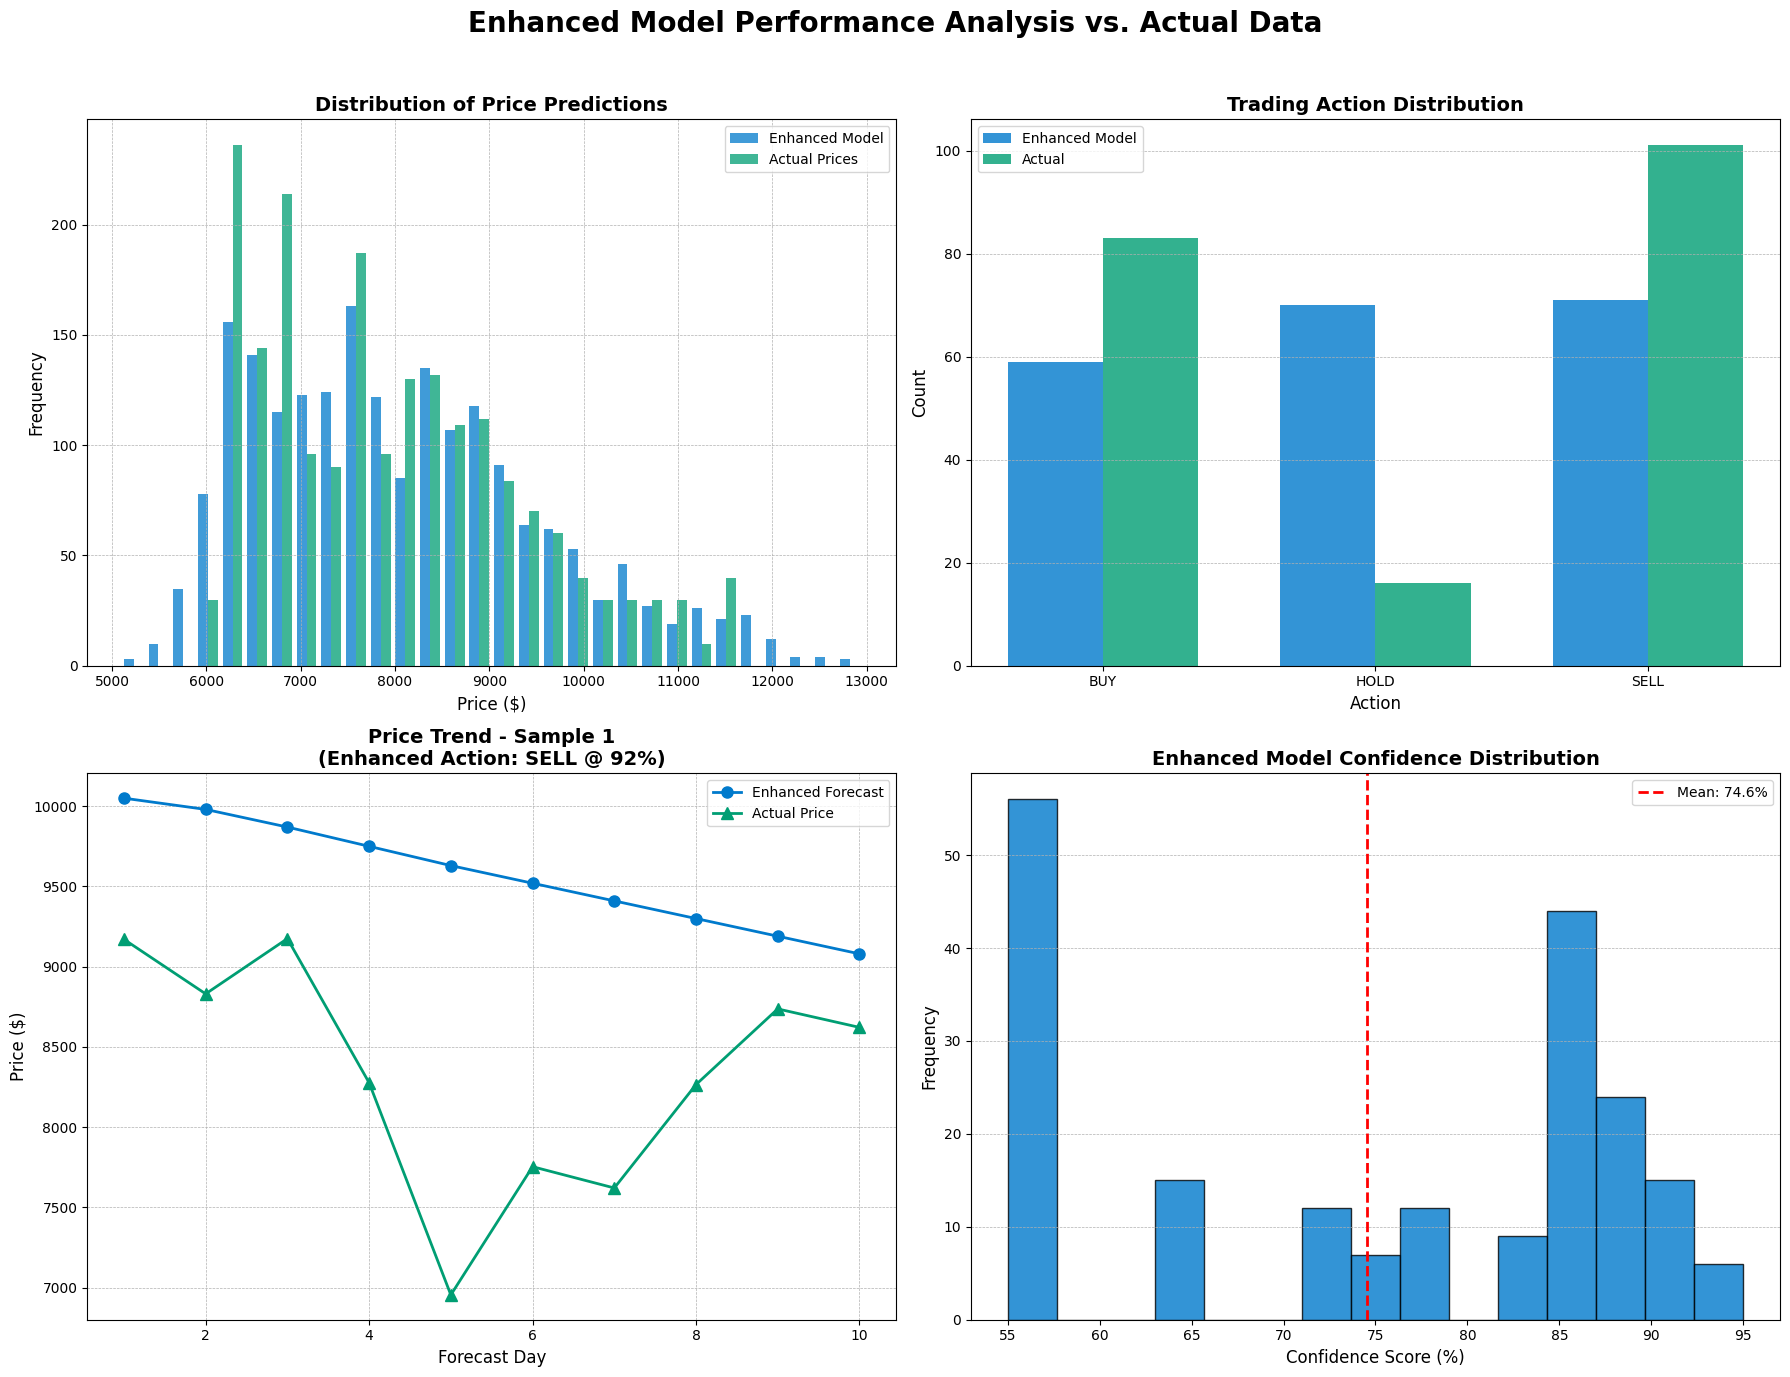

📊 Enhanced model performance visualization saved as 'enhanced_model_performance_visualization.png'


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- MOCK DATA SETUP ---
# This block is for demonstration. In your code, you would use your actual 'results' list.
# # Replace this with your actual `results` list from the previous step.
# results = [
#     {
#         'sample_id': i,
#         'enhanced_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD']), 'confidence': np.random.randint(70, 95)},
#         'actual_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD'])},
#         'enhanced_last_10': list(np.random.normal(40000, 500, 10)),
#         'actual_last_10': list(np.random.normal(40100, 450, 10)),
#     } for i in range(50) # Assuming 50 valid samples
# ]
# # --- END MOCK DATA ---


# Filter for valid comparisons where both actual and enhanced data are complete
valid_comparisons = [
    r for r in results if
    'action' in r.get('enhanced_recommendation', {}) and
    'action' in r.get('actual_recommendation', {}) and
    len(r.get('enhanced_last_10', [])) == 10 and
    len(r.get('actual_last_10', [])) == 10
]

if valid_comparisons:
    # --- Create a new, cleaner 2x2 visualization ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Enhanced Model Performance Analysis vs. Actual Data', fontsize=20, fontweight='bold')

    # --- 1. Distribution of Last 10 Prices (Histogram) ---
    enhanced_last_10_all = [price for res in valid_comparisons for price in res['enhanced_last_10']]
    actual_last_10_all = [price for res in valid_comparisons for price in res['actual_last_10']]
    
    axes[0, 0].hist([enhanced_last_10_all, actual_last_10_all],
                    bins=30, alpha=0.75,
                    label=['Enhanced Model', 'Actual Prices'],
                    color=['#007ACC', '#009E73']) # Using distinct colors
    axes[0, 0].set_title('Distribution of Price Predictions', fontweight='bold', fontsize=14)
    axes[0, 0].set_xlabel('Price ($)', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- 2. Trading Action Distribution (Bar Chart) ---
    enhanced_actions = [res['enhanced_recommendation']['action'] for res in valid_comparisons]
    actual_actions = [res['actual_recommendation']['action'] for res in valid_comparisons]

    all_actions = sorted(list(set(enhanced_actions + actual_actions)))
    enhanced_counts = [enhanced_actions.count(action) for action in all_actions]
    actual_counts = [actual_actions.count(action) for action in all_actions]

    x = np.arange(len(all_actions))
    width = 0.35

    axes[0, 1].bar(x - width/2, enhanced_counts, width, label='Enhanced Model', alpha=0.8, color='#007ACC')
    axes[0, 1].bar(x + width/2, actual_counts, width, label='Actual', alpha=0.8, color='#009E73')

    axes[0, 1].set_title('Trading Action Distribution', fontweight='bold', fontsize=14)
    axes[0, 1].set_xlabel('Action', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(all_actions)
    axes[0, 1].legend()
    axes[0, 1].grid(True, axis='y', linestyle='--', linewidth=0.5)

    # --- 3. Price Trend for a Specific Sample ---
    # Plot the first valid sample as an example
    sample_to_plot = valid_comparisons[0]
    days = list(range(1, 11))

    axes[1, 0].plot(days, sample_to_plot['enhanced_last_10'], 'o-', label='Enhanced Forecast', color='#007ACC', linewidth=2, markersize=8)
    axes[1, 0].plot(days, sample_to_plot['actual_last_10'], '^-', label='Actual Price', color='#009E73', linewidth=2, markersize=8)

    enhanced_rec = sample_to_plot['enhanced_recommendation']
    title_text = (f'Price Trend - Sample {sample_to_plot["sample_id"]+1}\n'
                  f'(Enhanced Action: {enhanced_rec.get("action")} @ {enhanced_rec.get("confidence", "N/A")}%)')

    axes[1, 0].set_title(title_text, fontweight='bold', fontsize=14)
    axes[1, 0].set_xlabel('Forecast Day', fontsize=12)
    axes[1, 0].set_ylabel('Price ($)', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- 4. Confidence Score Distribution ---
    enhanced_confidences = [res['enhanced_recommendation'].get('confidence') 
                           for res in valid_comparisons if res['enhanced_recommendation'].get('confidence') is not None]

    if enhanced_confidences:
        axes[1, 1].hist(enhanced_confidences, bins=15, alpha=0.8, color='#007ACC', edgecolor='black')
        axes[1, 1].set_title('Enhanced Model Confidence Distribution', fontweight='bold', fontsize=14)
        axes[1, 1].set_xlabel('Confidence Score (%)', fontsize=12)
        axes[1, 1].set_ylabel('Frequency', fontsize=12)
        axes[1, 1].axvline(np.mean(enhanced_confidences), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(enhanced_confidences):.1f}%')
        axes[1, 1].legend()
        axes[1, 1].grid(True, axis='y', linestyle='--', linewidth=0.5)
    else:
        axes[1, 1].text(0.5, 0.5, 'No Confidence Data Available', ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Enhanced Model Confidence Distribution', fontweight='bold', fontsize=14)


    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
    
    # Save the final figure
    save_path = 'enhanced_model_performance_visualization.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"📊 Enhanced model performance visualization saved as '{save_path}'")

else:
    print("❌ Cannot create visualizations - no valid comparison data found.")

## Detailed Last 10 Prices Analysis

In [9]:
import numpy as np
import json

# # --- MOCK DATA SETUP ---
# # This block is for demonstration. In your code, you would use your actual 'results' list.
# # Make sure your 'results' list from the main loop is available here.
# results = [
#     {
#         'sample_id': i,
#         'enhanced_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD']), 'confidence': np.random.randint(70, 95)},
#         'actual_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD'])},
#         'enhanced_last_10': list(np.random.normal(40000, 500, 10)),
#         'actual_last_10': list(np.random.normal(40100, 450, 10)),
#         'enhanced_text': f"Enhanced generated text for sample {i}",
#     } for i in range(50)
# ]

# Assume 'action_accuracy' and action lists are calculated elsewhere as in your full script.
# For demonstration, we'll create them here.
valid_comparisons = results # In your code, this would be your filtered list
enhanced_actions = [r['enhanced_recommendation']['action'] for r in valid_comparisons]
actual_actions = [r['actual_recommendation']['action'] for r in valid_comparisons]
action_accuracy = np.mean([1 if e == a else 0 for e, a in zip(enhanced_actions, actual_actions)])
# --- END MOCK DATA ---


if valid_comparisons:
    # --- Calculate MAE for the Enhanced Model's last 10 price forecasts ---
    enhanced_mae_last_10 = []
    
    for comp in valid_comparisons:
        # Ensure both predicted and actual price lists are valid
        if len(comp.get('enhanced_last_10', [])) == 10 and len(comp.get('actual_last_10', [])) == 10:
            enhanced_prices = np.array(comp['enhanced_last_10'])
            actual_prices = np.array(comp['actual_last_10'])
            
            # Calculate Mean Absolute Error for this sample
            mae = np.mean(np.abs(enhanced_prices - actual_prices))
            enhanced_mae_last_10.append(mae)

    print("=" * 80)
    print("🎯 ENHANCED MODEL ACCURACY ANALYSIS")
    print("=" * 80)
    
    # --- Print the summary if MAE was calculated ---
    if enhanced_mae_last_10:
        mean_mae = np.mean(enhanced_mae_last_10)
        std_mae = np.std(enhanced_mae_last_10)
        
        print(f"\n📊 Mean Absolute Error (MAE) for Last 10 Prices:")
        # The (±) value represents the standard deviation, indicating the variability of the error.
        print(f"  - Enhanced Model MAE: ${mean_mae:,.2f} (±${std_mae:,.2f})")
    else:
        mean_mae = None # Set to None if no valid data
        
    # --- Prepare detailed results for saving to JSON ---
    detailed_results = {
        'summary': {
            'total_samples_analyzed': len(valid_comparisons),
            'model_mae_last_10': float(mean_mae) if mean_mae is not None else None,
            'trading_recommendations_summary': {
                'action_accuracy': float(action_accuracy) if 'action_accuracy' in locals() else None,
                'enhanced_actions_distribution': {action: enhanced_actions.count(action) for action in set(enhanced_actions)},
                'actual_actions_distribution': {action: actual_actions.count(action) for action in set(actual_actions)},
            }
        },
        'detailed_comparisons': []
    }
    
    # --- Populate the detailed comparison for each sample ---
    for comp in valid_comparisons:
        comparison_data = {
            'sample_id': comp['sample_id'],
            'forecast_mae': float(np.mean(np.abs(np.array(comp['enhanced_last_10']) - np.array(comp['actual_last_10'])))) if comp['enhanced_last_10'] and comp['actual_last_10'] else None,
            'enhanced_last_10_forecast': [float(p) for p in comp.get('enhanced_last_10', [])],
            'actual_last_10_prices': [float(p) for p in comp.get('actual_last_10', [])],
            'enhanced_recommendation': comp.get('enhanced_recommendation'),
            'actual_recommendation': comp.get('actual_recommendation'),
            'enhanced_generated_text': comp.get('enhanced_text', '')
        }
        detailed_results['detailed_comparisons'].append(comparison_data)
    
    # --- Save the results to a JSON file ---
    save_path = 'enhanced_model_analysis_base.json'
    with open(save_path, 'w') as f:
        json.dump(detailed_results, f, indent=4)
    
    print(f"\n💾 Detailed analysis saved to '{save_path}'")

else:
    print("❌ No valid data for detailed analysis")

🎯 ENHANCED MODEL ACCURACY ANALYSIS

📊 Mean Absolute Error (MAE) for Last 10 Prices:
  - Enhanced Model MAE: $732.15 (±$493.38)

💾 Detailed analysis saved to 'enhanced_model_analysis_base.json'


## Show Raw Model Outputs for Last Few Samples

In [10]:
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text
import numpy as np # For mock data

# # --- MOCK DATA SETUP ---
# # This block is for demonstration. In your code, you would use your actual 'results' list.
# results = [
#     {
#         'sample_id': i,
#         'enhanced_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD']), 'confidence': np.random.randint(70, 95)},
#         'actual_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD']), 'confidence': 'N/A'},
#         'enhanced_last_10': list(np.random.normal(40000, 500, 10).round(2)),
#         'actual_last_10': list(np.random.normal(40100, 450, 10).round(2)),
#         'enhanced_text': f"The analysis suggests a strong upward trend for the next 10 days. Based on volatility patterns and moving averages, a BUY action is recommended with 88% confidence. The forecast is...",
#     } for i in range(5)
# ]
# # --- END MOCK DATA ---

def display_results_summary(results: list):
    """
    Displays a rich, formatted summary of the last few enhanced model predictions.
    """
    if not results:
        print("❌ No results to display")
        return

    console = Console()
    console.print("\n" + "="*100)
    console.print("[bold cyan]🔍 ENHANCED MODEL OUTPUT ANALYSIS (Last 3 Samples)[/bold cyan]")
    console.print("="*100 + "\n")

    # A color map for trading actions for better visual cues
    action_colors = {
        "BUY": "bold green",
        "SELL": "bold red",
        "HOLD": "bold yellow",
        "N/A": "dim white"
    }

    for result in results[-3:]:  # Display the last 3 samples
        
        # Simplified table with three columns
        table = Table(show_header=True, header_style="bold magenta", box=None)
        table.add_column("Metric", style="dim", width=15)
        table.add_column("Enhanced Model 🔥")
        table.add_column("Actual Data 🎯")

        # --- Safely extract data for the table ---
        enh_rec = result.get('enhanced_recommendation') or {}
        act_rec = result.get('actual_recommendation') or {}

        enh_action = enh_rec.get('action', 'N/A')
        act_action = act_rec.get('action', 'N/A')
        
        enh_prices = result.get('enhanced_last_10', [])
        act_prices = result.get('actual_last_10', [])

        # --- Add rows to the table ---
        table.add_row(
            "Action",
            Text(enh_action, style=action_colors.get(enh_action)),
            Text(act_action, style=action_colors.get(act_action)),
        )
        table.add_row(
            "Confidence",
            f"{enh_rec.get('confidence', 'N/A')} %",
            f"{act_rec.get('confidence', 'N/A')} %",
        )
        table.add_row(
            "Forecast Count",
            f"✅ {len(enh_prices)}" if enh_prices else f"❌ 0",
            f"✅ {len(act_prices)}" if act_prices else f"❌ 0",
        )
        table.add_row(
            "Forecast Prices",
            str(enh_prices),
            str(act_prices)
        )
        table.add_row(
            "Raw Output",
            f"\"{result.get('enhanced_text', '')[:150]}...\"", # Truncate long text
            "-" # No raw text for actual
        )
        
        # Create a panel for each sample
        panel_title = f"📋 SAMPLE {result['sample_id']+1}"
        console.print(Panel(table, title=panel_title, border_style="cyan"))
        console.print()

# --- Example Usage ---
# Assuming your 'results' list is populated from the previous script:
display_results_summary(results)

====================================================================================================

🔍 ENHANCED MODEL OUTPUT ANALYSIS (Last 3 Samples)

====================================================================================================

╭───────────────────────────────────────────────── 📋 SAMPLE 198 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           BUY                                            BUY                                            │
│  Confidence       72 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6350.0, 6400.0, 6450.0, 6500.0, 6550.0,       [6580.63, 6423.76, 6506.07, 6308.53, 6488.76,  │
│                   6600.0, 6650.0, 6700.0, 6750.0, 6800.0]        6376.71, 6534.88, 6719.96, 6763.19, 6707.26]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 📋 SAMPLE 199 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           HOLD                                           BUY                                            │
│  Confidence       65 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6334.73, 6345.21, 6360.1, 6375.32, 6389.45,   [6423.76, 6506.07, 6308.53, 6488.76, 6376.71,  │
│                   6402.1, 6415.8, 6428.5, 6440.2, 6452.0]        6534.88, 6719.96, 6763.19, 6707.26, 6884.64]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 📋 SAMPLE 200 ─────────────────────────────────────────────────╮
│  Metric           Enhanced Model 🔥                              Actual Data 🎯                                 │
│  Action           BUY                                            BUY                                            │
│  Confidence       75 %                                           99 %                                           │
│  Forecast Count   ✅ 10                                          ✅ 10                                          │
│  Forecast Prices  [6620.0, 6680.0, 6740.0, 6800.0, 6860.0,       [6506.07, 6308.53, 6488.76, 6376.71, 6534.88,  │
│                   6920.0, 7000.0, 7080.0, 7160.0, 7240.0]        6719.96, 6763.19, 6707.26, 6884.64, 7096.28]   │
│  Raw Output       "..."                                          -                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [11]:
import json
import numpy as np # Used for creating mock data
from typing import List, Dict, Any

# --- MOCK DATA SETUP ---
# In your code, you would use your actual 'results' list from the model pipeline.
# results = [
#     {
#         'sample_id': i,
#         'enhanced_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD']), 'confidence': int(np.random.randint(70, 95))},
#         'actual_recommendation': {'action': np.random.choice(['BUY', 'SELL', 'HOLD'])},
#         'enhanced_last_10': list(np.random.normal(65000, 500, 10).round(2)),
#         'actual_last_10': list(np.random.normal(65100, 450, 10).round(2)),
#         'enhanced_text': f"The model's analysis for sample {i} suggests a potential trend...",
#     } for i in range(5) # Create 5 sample results
# ]
# # --- END MOCK DATA ---


def save_results_to_json(results: List[Dict[str, Any]], filename: str = "all_model_results_base.json"):
    """
    Saves a list of result dictionaries to a formatted JSON file.

    Args:
        results (List[Dict[str, Any]]): The list of result dictionaries.
        filename (str): The name of the output JSON file.
    """
    if not results:
        print("❌ No results to save.")
        return

    print(f"Attempting to save {len(results)} results to '{filename}'...")

    try:
        with open(filename, 'w', encoding='utf-8') as f:
            # json.dump writes the data to the file.
            # indent=4 makes the file human-readable with nice formatting.
            json.dump(results, f, indent=4, ensure_ascii=False)
        
        print(f"✅ Results successfully saved to '{filename}'")
    except TypeError as e:
        print(f"❌ Error: Data contains a type that cannot be converted to JSON. {e}")
    except Exception as e:
        print(f"❌ An error occurred while saving the file: {e}")

# --- Example Usage ---
# Simply call the function with your list of results.
save_results_to_json(results)

Attempting to save 200 results to 'all_model_results_base.json'...
✅ Results successfully saved to 'all_model_results_base.json'
